In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Exercise 4

In this exercise, we will try to solve the viscous Burgers equation
$$
\begin{align*}
\partial_t u(x,t) + \frac{1}{2}\partial_x (u(x,t)^2) = \epsilon\partial_{xx}u(x,t) ,&& -1<x<1,\,t>0,\\
u(-1,t) = g_L(t), && t>0,\\
u(1,t) = g_R(t), && t>0,\\
u(x,0) = \eta(x), && -1<x<1.
\end{align*}
$$

We will now use the method of manufactured solution to determine the initial and boundary conditions by assuming we can write the solution on the form
$$
u(x,t) = -\tanh \left(\frac{x + 0.5 - t}{2\epsilon}\right) +1
$$

We can now determine the initial and boundary condition by insertion of the solution into the equation.

In [16]:
def u(x, t, eps):
    return -sp.tanh((x + 0.5 -t)/(2*eps)) + 1
def u2(x, t, eps):
    return (-sp.tanh((x + 0.5 -t)/(2*eps)) + 1)**2

x = sp.symbols('x')
t = sp.symbols('t')
eps = sp.symbols('eps')

print(u(-1, t, eps))
print(u(1, t, eps))
print(u(x, 0, eps))

1 - tanh((-t - 0.5)/(2*eps))
1 - tanh((1.5 - t)/(2*eps))
1 - tanh((x + 0.5)/(2*eps))


In [21]:
lhs = sp.diff(u(x, t, eps), t) + sp.Rational(1, 2)*sp.diff(u2(x, t, eps), x)
rhs = eps*sp.diff(u(x, t, eps), x, 2)
sp.simplify(lhs - rhs) == 0

True

We see it is indeed a solution if we choose;
$$
\begin{align*}
    g_L(t) &= 1 - \tanh((-t - 0.5)/(2\epsilon))\\
    g_R(t) &= 1 - \tanh((1.5 - t)/(2\epsilon))\\
    \eta(x) &= 1 - \tanh((x + 0.5)/(2\epsilon))
\end{align*}
$$

### 1)

Combining the lessons from Exercises 2 and 3, we use:
- **Forward Euler** for the time derivative $\partial_t u$
- **Upwind (FTBS)** for the nonlinear advection term $\frac{1}{2}\partial_x(u^2)$, as in Exercise 3
- **Central differences** for the diffusion term $\epsilon \partial_{xx}u$, as in Exercise 2

For each term of the PDE we get:
$$
\begin{align*}
\partial_t u &= \frac{u^{n+1}_i-u^{n}_i}{k} \\
\partial_x (\frac12 u^2) &= \partial_x f(u) = \frac{f(u^{n}_i)-f(u^{n}_{i-1})}{h} = \frac{(u^{n}_i)^2-(u^{n}_{i-1})^2}{2h} \\
\epsilon \partial_{xx} u &= \frac{\epsilon}{h^2}(u^{n}_{i-1} - 2u^{n}_{i} + u^{n}_{i+1})
\end{align*}
$$
Inserting in the PDE and isolating $u_i^{n+1}$:

$$u_i^{n+1} = u_i^n - \frac{k}{2h}\left[(u_i^n)^2 - (u_{i-1}^n)^2\right] + \frac{\epsilon k}{h^2}\left[u_{i+1}^n - 2u_i^n + u_{i-1}^n\right]$$

We use Von Neumann stability analysis (as in exercise 3), first by considering the diffusion scheme alone (no advection term). We can do this because we later will linearize the advection term, this is done by assuming $u$ does not change much between timesteps. Therefore, when writing the full scheme, we would get two linear terms, which can be considered as ONE operator, therefore we can make Von Neumann analysis on each term separately. We start with the diffusion term:
$$u_i^{n+1} = u_i^n + \frac{\epsilon k}{h^2}\left[u_{i+1}^n - 2u_i^n + u_{i-1}^n\right]$$
We substitute $u_j^n = g^ne^{i\xi j h}$
$$
g^{n+1}e^{i\xi j h} = g^ne^{i\xi j h} + \frac{\epsilon k}{h^2}\left[g^ne^{i\xi (j+1) h} - 2g^ne^{i\xi j h} + g^ne^{i\xi (j-1) h}\right]
$$
and divide by $g^ne^{i\xi j h}$
$$
g = 1 + \frac{\epsilon k}{h^2}(e^{i\xi h} - 2 + e^{-i\xi h}) = 1 + \frac{\epsilon k}{h^2}(2\cos(\xi h) - 2) = 1- 4\frac{\epsilon k}{h^2}\sin^2(\xi h/2)
$$
We see that $1-4\frac{\epsilon k}{h^2} \leq g \leq 1$ so for $|g| \leq 1$ we need $g \geq -1$, since the upper bound is automatic (from $max(\xi h)$) we get:
$$
1-4\frac{\epsilon k}{h^2} \geq -1 \Rightarrow k \geq \frac{h^2}{2\epsilon}
$$
To analyze the nonlinear advection part we need to make some approximations in order to apply Von Neumann analysis, we rewrite the nonlinear term to locally linear term:
$$
(u_i^n)^2 - (u_{i-1}^n)^2 = (u_i^n + u_{i-1}^n)(u_i^n - u_{i-1}^n)
$$
So the advection term becomes:
$$
- \frac{k}{2h}\left[(u_i^n)^2 - (u_{i-1}^n)^2\right] = -\frac{k}{h}\frac{u^n_i+u^n_{i-1}}{2}(u^n_{i}- u^n_{i-1})
$$
This looks like a linear scheme (here with a local wave speed).


We now make the assumption that $u$ does not change a lot from timestep to timestep, that it is almost constant, this is an ok assumption since stability is a local property, a scheme can be stable for one part of the domain but not for another. Therefore we can freeze $u$ (denoted $\tilde{u}$) and assume it constant. The scheme then becomes:
$$
u^{n+1}_i = u^{n}_i - \frac{\tilde{u}k}{h}(u^n_i - u_{i-1}^n)
$$
We apply Von Neumann as before, which gives:
$$
\frac{\tilde{u}k}{h} \leq 1
$$
Now, since $\tilde{u}$ varies across the domain, we take the worst possible case on the domain and obtain:
$$
k \leq \frac{h}{\max|u|}
$$

We need both advection and diffusion to be stable, therefore $k$ must fulfill:
$$k \leq \min\!\left(\frac{h^2}{2\epsilon},\; \frac{h}{\max|u|}\right)$$

### 2)

In [ ]:
def solve_burgers(N, T, eps, gL, gR, eta):
    """
    Solve viscous Burgers equation on [-1,1] x [0,T].
    Upwind (FTBS) for advection + central FD for diffusion.
    Convention (matching Exercise 2):
      N   : number of spatial intervals  →  N+1 grid points, h = 2/N
      T   : final time
      eps : diffusion coefficient epsilon
      gL  : callable gL(t) — left Dirichlet BC
      gR  : callable gR(t) — right Dirichlet BC
      eta : callable eta(x) — initial condition
    """
    x = np.linspace(-1, 1, N + 1)   # N intervals → N+1 points (matches Exercise 2)
    h = 2 / N

    # Time step: satisfy both stability conditions simultaneously (safety factor 0.4
    # as in Exercise 2).  max|u| ≤ 2 for the tanh exact solution.
    max_u = 2.0
    k = 0.4 * min(h**2 / (2 * eps), h / max_u)

    u = eta(x)
    u[0]  = gL(0)
    u[-1] = gR(0)

    t = 0.0
    while t < T - 1e-14:
        if t + k > T:
            k = T - t

        u_new = u.copy()
        # Interior points: upwind flux for advection + central stencil for diffusion
        u_new[1:-1] = (u[1:-1]
                       - (k / (2 * h)) * (u[1:-1]**2 - u[:-2]**2)
                       + (eps * k / h**2) * (u[2:] - 2*u[1:-1] + u[:-2]))
        # Dirichlet boundary conditions at new time level
        u_new[0]  = gL(t + k)
        u_new[-1] = gR(t + k)

        u = u_new
        t += k

    return x, u

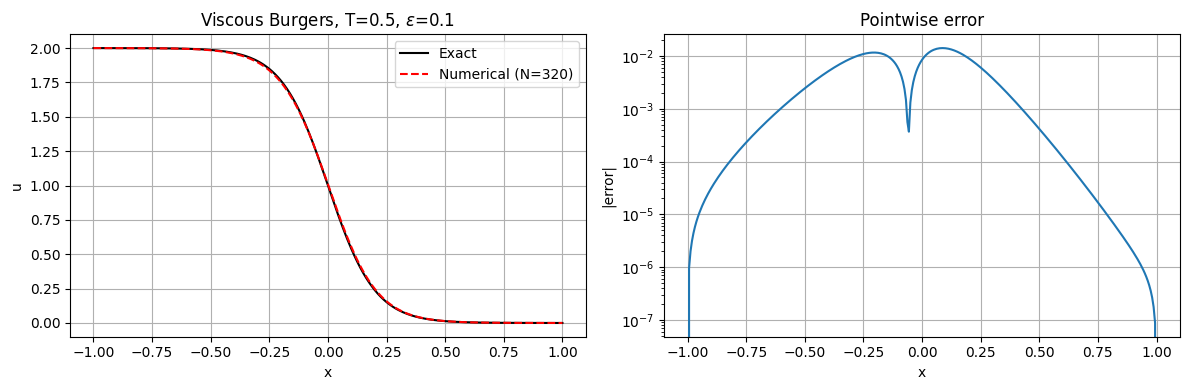

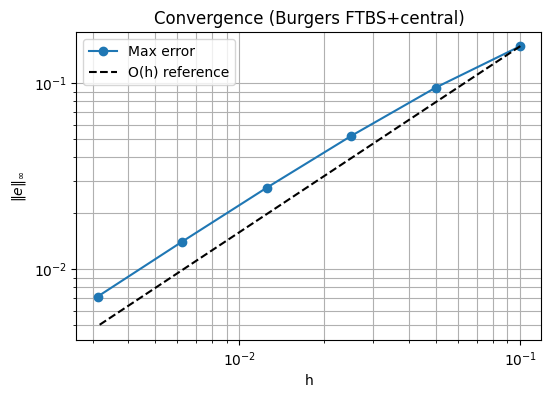

h       error      rate
0.1000   1.59e-01   —
0.0500   9.50e-02   0.74
0.0250   5.22e-02   0.86
0.0125   2.75e-02   0.93
0.0063   1.41e-02   0.96
0.0031   7.15e-03   0.98


In [7]:
# Exact solution (numpy version)
def u_exact(x, t, eps):
    return -np.tanh((x + 0.5 - t) / (2 * eps)) + 1

eps_val = 0.1
T_val   = 0.5

gL  = lambda t: u_exact(-1, t, eps_val)
gR  = lambda t: u_exact( 1, t, eps_val)
eta = lambda x: u_exact(x,  0, eps_val)

# --- Quick visual check ---
N = 320   # intervals (h = 2/100 = 0.02), matching Exercise 2 convention
x_num, u_num = solve_burgers(N, T_val, eps_val, gL, gR, eta)
u_ref = u_exact(x_num, T_val, eps_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x_num, u_ref, 'k-',  label='Exact')
axes[0].plot(x_num, u_num, 'r--', label=f'Numerical (N={N})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('u')
axes[0].set_title(rf'Viscous Burgers, T={T_val}, $\epsilon$={eps_val}')
axes[0].grid()
axes[0].legend()
axes[1].semilogy(x_num, np.abs(u_num - u_ref))
axes[1].set_xlabel('x'); axes[1].set_ylabel('|error|')
axes[1].set_title('Pointwise error')
axes[1].grid()
plt.tight_layout()
plt.show()

# --- Convergence in h (k chosen by stability, exactly as in Exercise 2) ---
Ns = [20, 40, 80, 160, 320, 640]
hs, errors = [], []

for N in Ns:
    x_n, u_n = solve_burgers(N, T_val, eps_val, gL, gR, eta)
    err = np.max(np.abs(u_n - u_exact(x_n, T_val, eps_val)))
    hs.append(2 / N)
    errors.append(err)

hs     = np.array(hs)
errors = np.array(errors)
rates  = np.log(errors[:-1] / errors[1:]) / np.log(hs[:-1] / hs[1:])

plt.figure(figsize=(6, 4))
plt.loglog(hs, errors,              'o-',  label='Max error')
plt.loglog(hs, errors[0]*(hs/hs[0]),  'k--', label='O(h) reference')
plt.xlabel('h'); plt.ylabel(r'$\|e\|_\infty$')
plt.title('Convergence (Burgers FTBS+central)')
plt.legend(); plt.grid(which='both')
plt.show()

print("h       error      rate")
for i, (h, e) in enumerate(zip(hs, errors)):
    rate_str = f"{rates[i-1]:.2f}" if i > 0 else "—"
    print(f"{h:.4f}   {e:.2e}   {rate_str}")


We see that the error is largest around the steeper gradient at $x=0$, but the errors are stille relatively low and the solution looks like it fits fine to the exact solution. 

We get out expected convergence of $\mathcal{O}(h)$, this expectation comes from our combination of two 1st order accurate method, we see in exercise 2 and 3 that the methods are $\mathcal{O}(h)$ convergent, so a linear combination of these methods will also produce $\mathcal{O}(h)$ convergence

### 3)

We now solve the same viscous Burgers equation, but with a **different IBVP**:

$$
g_L(t) = g_R(t) = 0, \qquad \eta(x) = -\sin(\pi x), \qquad \epsilon = \frac{0.01}{\pi}
$$

The solution develops a very steep gradient near $x = 0$ as time progresses. We use the `solve_burgers` scheme from Task 2 on a **fine uniform mesh** and estimate

$$
\partial_x u\big|_{x=0} \approx \frac{u_{i_0+1} - u_{i_0-1}}{2h}
$$

at $t = 1.6037/\pi$, targeting the value $-152.00516$.


Uniform grid: N = 4000, h = 0.000500
x[i0] = 0.000000 (should be 0)
du/dx|_{x=0} = -151.21478
Target = -152.00516
Error = 0.79038


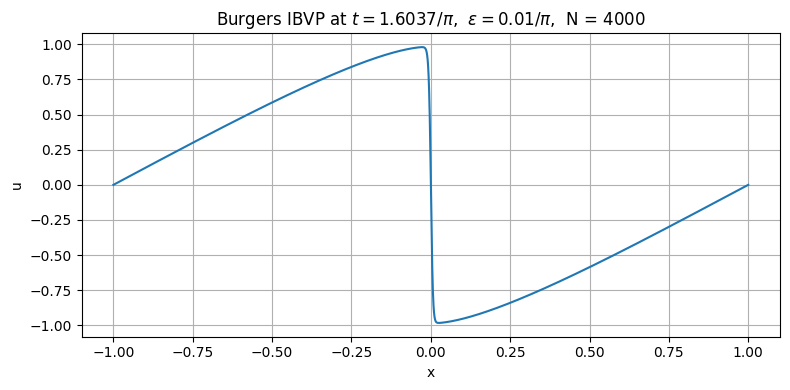

In [8]:
eps3   = 0.01 / np.pi
T3     = 1.6037 / np.pi
target = -152.00516

gL3  = lambda t: 0.0
gR3  = lambda t: 0.0
eta3 = lambda x: -np.sin(np.pi * x)

# Fine uniform mesh
N_uni = 4000
x_uni, u_uni = solve_burgers(N_uni, T3, eps3, gL3, gR3, eta3)

# Estimate du/dx at x=0 via central difference (x=0 is exactly at index N_uni//2)
i0   = N_uni // 2
h_u  = 2 / N_uni
dudx_uni = (u_uni[i0 + 1] - u_uni[i0 - 1]) / (2 * h_u)

print(f"Uniform grid: N = {N_uni}, h = {h_u:.6f}")
print(f"x[i0] = {x_uni[i0]:.6f} (should be 0)")
print(f"du/dx|_{{x=0}} = {dudx_uni:.5f}")
print(f"Target = {target:.5f}")
print(f"Error = {abs(dudx_uni - target):.5f}")

plt.figure(figsize=(8, 4))
plt.plot(x_uni, u_uni)
plt.xlabel('x')
plt.ylabel('u')
plt.title(rf'Burgers IBVP at $t = 1.6037/\pi$,  $\epsilon = 0.01/\pi$,  N = {N_uni}')
plt.grid()
plt.tight_layout()
plt.show()


We are quite close to the gradient, but we see that the scheme has a hard time estimating gradients that are almost shock-like, such a steep gradient is hard to estimate with a $\mathcal{O}(h)$ convergent method, we get quite clsoe, but the error is still relatively high compared to results from the scheme on smoother problems

## Task 4) Non-uniform grid

The solution at $t=1.6037/\pi$ is smooth everywhere except near $x=0$, where the steep gradient is concentrated. A uniform grid wastes most of its points on the smooth flat regions on either side.

By using a sinh non-uniform grid

$$
x(\xi) = \frac{\sinh(\beta\,\xi)}{\sinh(\beta)}, \qquad \xi \in [-1,1] \text{ uniform},
$$

points cluster near $x = 0$. For $\beta = 3$ the local spacing near $x=0$ is $\approx 3.3$ finer than $2/N$, without adding any extra points.

The scheme is the same as Task 2, but adapted for non-uniform spacing:
- **Advection**: same upwind flux $(u_i^2 - u_{i-1}^2)/(2\,\Delta w_i)$ where $\Delta w_i = \frac{h_L+h_R}{2}$ is the local dual-cell width
- **Diffusion**: non-uniform second-derivative stencil $\frac{2}{h_L+h_R}\!\left(\frac{u_{i+1}-u_i}{h_R} - \frac{u_i-u_{i-1}}{h_L}\right)$

We compare the error in $\partial_x u|_{x=0}$ for the two approaches at the same $N$.


In [10]:
def sinh_grid(N, beta=3.0):
    """N+1 grid points on [-1,1] clustered near x=0 via sinh stretching."""
    xi = np.linspace(-1, 1, N + 1)
    return np.sinh(beta * xi) / np.sinh(beta)

def solve_burgers_nonuniform(x_grid, T, eps, gL, gR, eta):
    """
    Solve viscous Burgers on an arbitrary (non-uniform) grid.
    Same upwind flux as solve_burgers, but with local dual-cell width dw
    replacing the uniform h. Non-uniform diffusion stencil.
    """
    x   = x_grid.copy()
    h   = np.diff(x)           # h[j] = x[j+1] - x[j]
    h_L = h[:-1]               # left spacing at interior nodes
    h_R = h[1:]                # right spacing at interior nodes
    dw  = 0.5 * (h_L + h_R)   # dual-cell width (replaces h in uniform scheme)

    k = 0.4 * min(h.min()**2 / (2 * eps), h.min() / 2.0)

    u     = eta(x)
    u[0]  = gL(0)
    u[-1] = gR(0)

    t = 0.0
    while t < T - 1e-14:
        if t + k > T:
            k = T - t
        u_new = u.copy()
        # Upwind advection flux (same form as uniform solver, dw replaces h)
        adv  = (u[1:-1]**2 - u[:-2]**2) / (2 * dw)
        # Non-uniform central diffusion stencil
        diff = (2 / (h_L + h_R)) * ((u[2:] - u[1:-1]) / h_R - (u[1:-1] - u[:-2]) / h_L)
        u_new[1:-1] = u[1:-1] - k * adv + eps * k * diff
        u_new[0]  = gL(t + k)
        u_new[-1] = gR(t + k)
        u = u_new
        t += k
    return x, u

C:\Users\simon\AppData\Local\Temp\ipykernel_12056\4057827598.py:34: RuntimeWarning: overflow encountered in square
  - (k / (2 * h)) * (u[1:-1]**2 - u[:-2]**2)
C:\Users\simon\AppData\Local\Temp\ipykernel_12056\4057827598.py:34: RuntimeWarning: invalid value encountered in subtract
  - (k / (2 * h)) * (u[1:-1]**2 - u[:-2]**2)


$\beta$ = 3.0   (sinh stretching)
     N     h_unif    h_min_nu    Err uniform    Err non-unif
   200    0.01000    0.002995            nan         17.1988
   400    0.00500    0.001497        33.6782          5.7456
   800    0.00250    0.000749        14.5533          1.5775
  1600    0.00125    0.000374         4.5666          0.4045
  3200    0.00063    0.000187         1.2241          0.1018
  6400    0.00031    0.000094         0.3118          0.0255


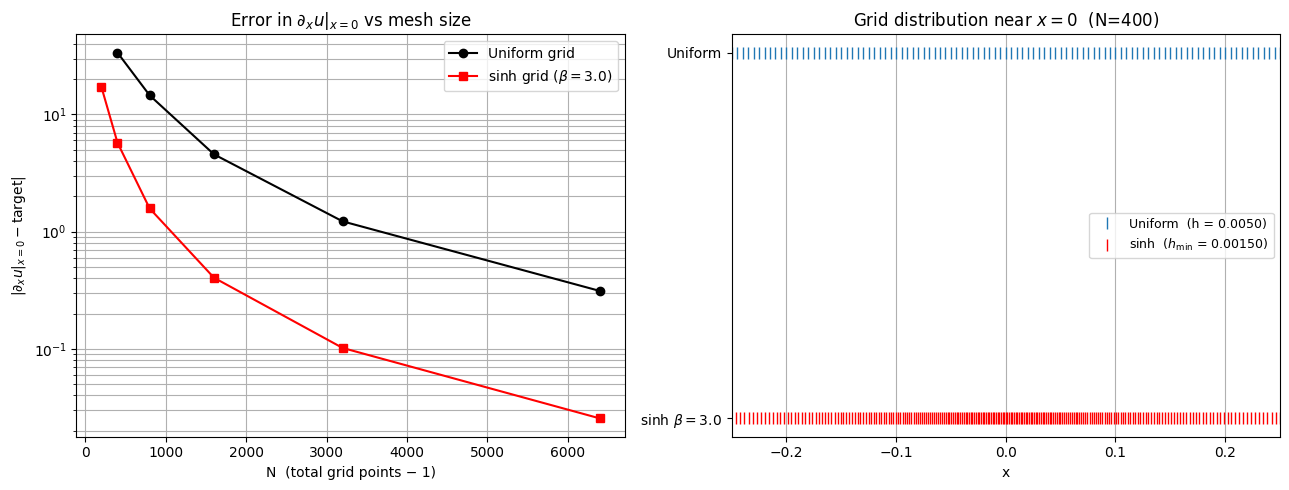

In [ ]:
beta = 3.0
Ns   = [200, 400, 800, 1600, 3200, 6400]

errs_uni, errs_nu, hs_uni, hs_min_nu = [], [], [], []

for N in Ns:
    #Uniform
    xu, uu = solve_burgers(N, T3, eps3, gL3, gR3, eta3)
    i0u = N // 2
    errs_uni.append(abs((uu[i0u+1] - uu[i0u-1]) / (xu[i0u+1] - xu[i0u-1]) - target))
    hs_uni.append(2 / N)

    #Non-uniform
    xn = sinh_grid(N, beta)
    _, un = solve_burgers_nonuniform(xn, T3, eps3, gL3, gR3, eta3)
    i0n = N // 2
    errs_nu.append(abs((un[i0n+1] - un[i0n-1]) / (xn[i0n+1] - xn[i0n-1]) - target))
    hs_min_nu.append(np.diff(xn).min())

# Print comparison table - Claude was used for formatting
print(rf"$\beta$ = {beta}   (sinh stretching)")
print(f"{'N':>6}  {'h_unif':>9}  {'h_min_nu':>10}  {'Err uniform':>13}  {'Err non-unif':>14}")
for i, N in enumerate(Ns):
    print(f"{N:>6}  {hs_uni[i]:>9.5f}  {hs_min_nu[i]:>10.6f}  {errs_uni[i]:>13.4f}  {errs_nu[i]:>14.4f}")

# --- Plot 1: Error vs N ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].semilogy(Ns, errs_uni, 'ko-', label='Uniform grid')
axes[0].semilogy(Ns, errs_nu,  'rs-', label=rf'sinh grid ($\beta={beta}$)')
axes[0].set_xlabel('N  (total grid points − 1)')
axes[0].set_ylabel(r'$|\partial_x u|_{x=0} - \mathrm{target}|$')
axes[0].set_title(r'Error in $\partial_x u|_{x=0}$ vs mesh size')
axes[0].legend(); axes[0].grid(which='both')

# --- Plot 2: Grid point distribution near x=0 ---
N_vis = 400
x_u = np.linspace(-1, 1, N_vis + 1)
x_n = sinh_grid(N_vis, beta)

axes[1].plot(x_u, np.ones_like(x_u) * 1.0, '|', ms=8,
             label=f'Uniform  (h = {2/N_vis:.4f})')
axes[1].plot(x_n, np.zeros_like(x_n),       '|', ms=8, color='r',
             label=rf'sinh  ($h_\min$ = {np.diff(x_n).min():.5f})')
axes[1].set_xlim(-0.25, 0.25)
axes[1].set_xlabel('x')
axes[1].set_yticks([0.0, 1.0])
axes[1].set_yticklabels([rf'sinh $\beta={beta}$', 'Uniform'])
axes[1].set_title(f'Grid distribution near $x=0$  (N={N_vis})')
axes[1].legend(fontsize=9); axes[1].grid(axis='x')

plt.tight_layout()
plt.show()

Wee see that choosing our grid points smarter (around the steepest part) gives us much better convergence for the same number of evaluations. There may be some computing of the gridpoints, but the performance is worth it. 

Choosing your grid points smarter with this scheme is a good idea with this problem, since we see such a performance boost.